# Machine Learning

## Progetto 4

Sviluppare una pipeline completa di Machine Learning per la Regressione, applicata al dataset multivariato **Diabetes**.
Effettuare il confronto e l'ottimizzazione dei seguenti modelli predittivi per stimare un valore target numerico continuo:

  - Regressione Lineare
  - Decision Tree
  - Regressione Ridge
  - Regressione Lasso
  - K-Nearest Neighbor
  - Support Vector Machine

## 1  Data Exploration & Preprocessing

1. **Caricamento e Analisi** del dataset e fornire un'analisi descrittiva iniziale (i.e. df.describe())
2. **Visualizzazione** tramite strumenti grafici (istogrammi, boxplot, scatter_matrix) per comprendere la distribuzione delle feature e identificare potenziali correlazioni o outlier
3. **Preparazione** dei dati in set di Training e Test utilizzando la funzione train_test_split

## 2  Confronto e Selezione Iniziale dei Modelli

1. Implementare e confrontare almeno quattro algoritmi di Regressione standard
2. Utilizzare la K-Fold Cross-Validation per valutare le prestazioni medie di ciascun modello sul set di training
3. Basare il confronto sulla metrica NMSE (*Negative Mean Squared Error*)

## 3  Hyperparameters Tuning

1. **Grid Search** per ottimizzare un iperparametro cruciale
2. **Valutazione Finale** per calcolare e riportare le metriche finali (MSE, *R²*) sul set di Test utilizzando il modello ottimizzato

## 4  Analisi delle Performance

1. **Learning Curves** per il modello ottimizzato, valutando bias e varianza, e commentando la tendenza del modello a overfitting o underfitting

## 5  Visualizzazione con Data Reduction

1. **PCA** per ridurre lo spazio delle feature a due dimensioni (PC1 & PC2)
2. **Plot della Regressione** per visualizzare il piano di regressione del modello ottimizzato nello spazio bidimensionale

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.decomposition import PCA
from pandas.plotting import scatter_matrix
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import learning_curve, GridSearchCV, cross_val_score, KFold, train_test_split

### 1.   Data Exploration & Preprocessing

In [55]:
# Caricamento & Analisi

data = load_diabetes()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

df = X.copy()
df['target'] = y

df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


In [56]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


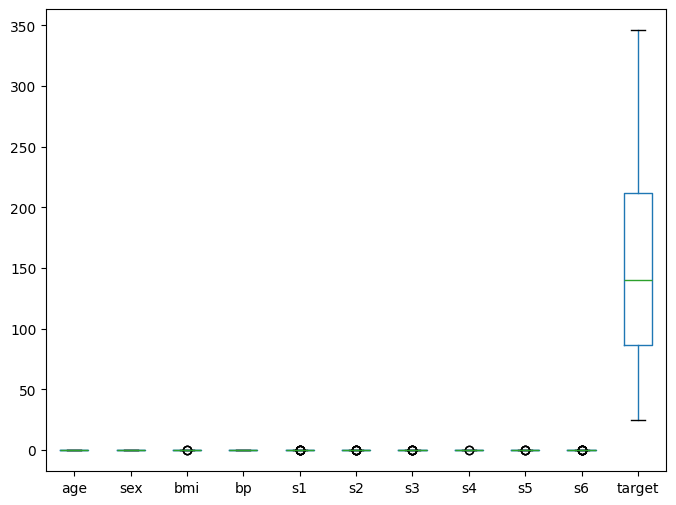

In [58]:
# Visualizzazione

df.boxplot(figsize=(8, 6), grid=False)
plt.show()

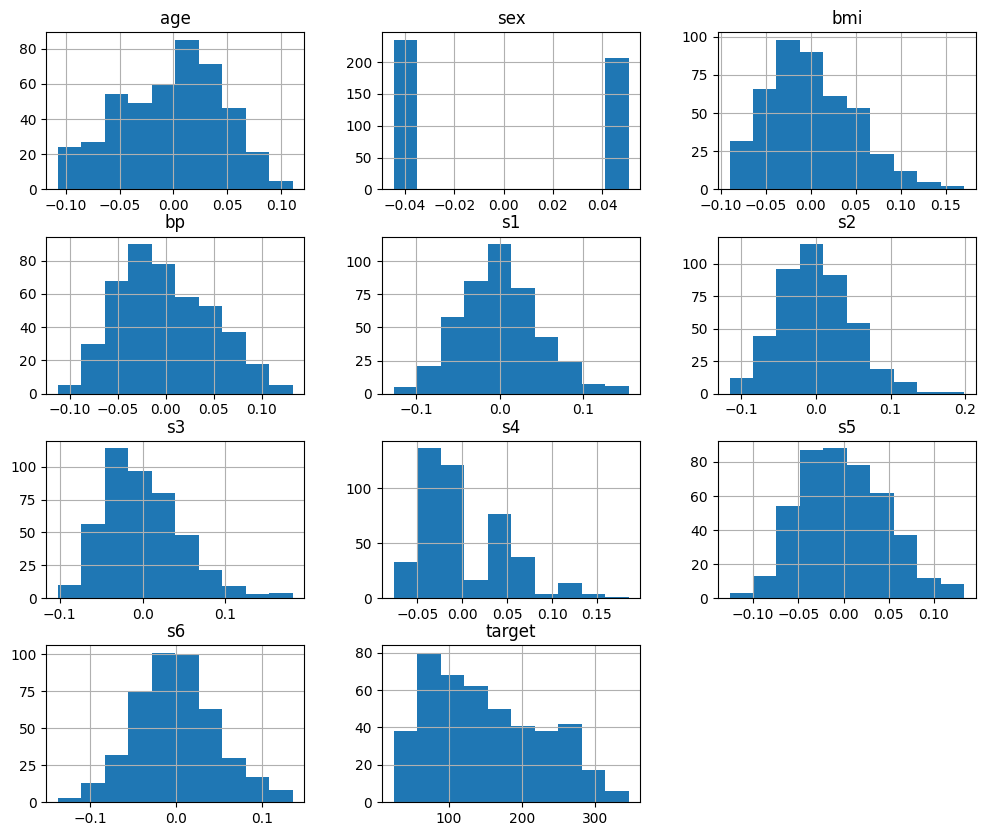

In [59]:
df.hist(figsize=(12,10))
plt.show()

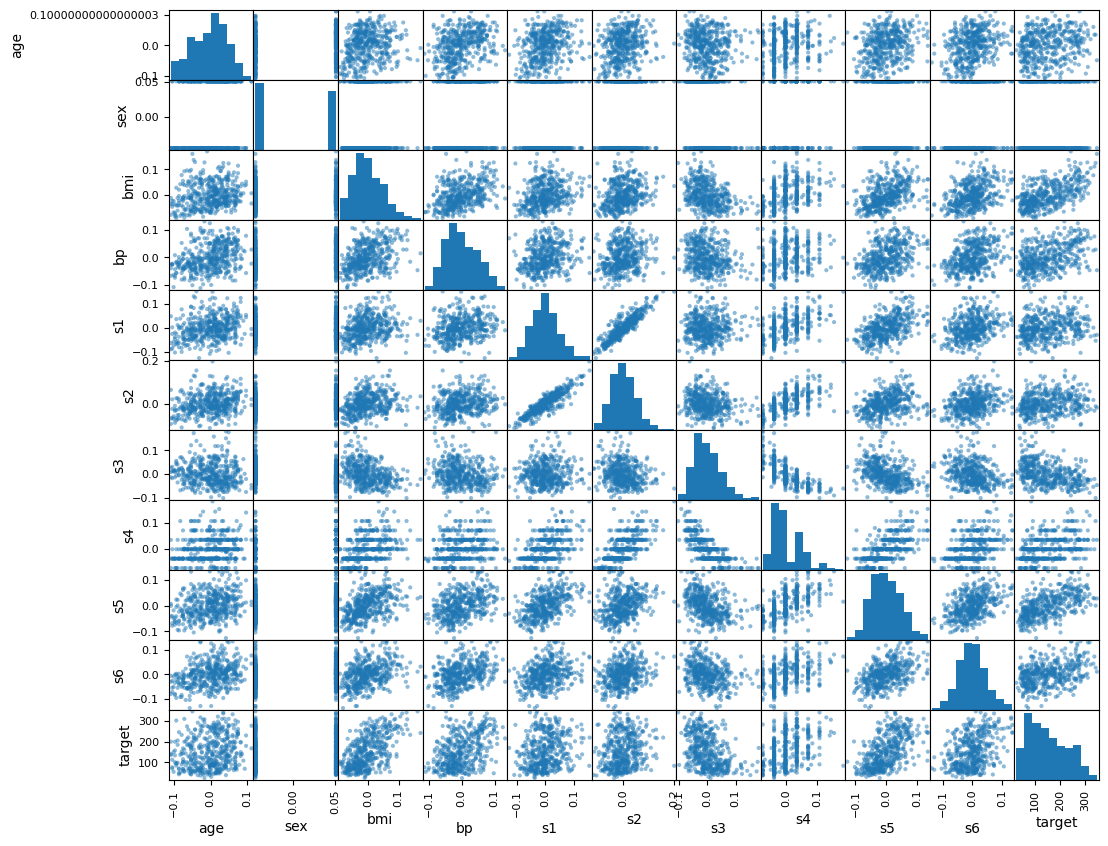

In [75]:
scatter_matrix(df, figsize=(12, 10))
plt.show()

Commento:

- Lo scatter matrix evidenzia relazioni deboli tra le variabili del dataset.
- Alcune feature mostrano una lieve correlazione con il target (es: BMI), ma non emergono pattern fortemente lineari. 
- Il problema risulta quindi adatto a modelli di regressione multivariata.

In [61]:
# Preparazione dei dati in set di Training e Test

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    shuffle=True,
    test_size=0.20,
    random_state=42
)

### 2.   Confronto e selezione iniziale dei modelli

In [62]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [63]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "KNN": KNeighborsRegressor(),
    "SVM": SVR()
}

In [64]:
# Cross Validation (Negative Mean Squared Error)

results = {}
K = 10

kfold = KFold(n_splits=K, shuffle=True, random_state=42)

for name, model in models.items():
    
    if name in ["KNN", "SVM", "Ridge", "Lasso"]:
        X_use = X_train_scaled
    else:
        X_use = X_train
    
    scores = cross_val_score(
        model,
        X_use,
        y_train,
        cv=kfold,
        scoring='neg_mean_squared_error'
    )
    
    results[name] = scores.mean()
    
    print(f"{name}:\n\t{scores.mean():.4f}")

Linear Regression:
	-3067.3095
Decision Tree:
	-6857.4398
Ridge:
	-3065.8272
Lasso:
	-3081.7230
KNN:
	-3902.6225
SVM:
	-5223.4655


Commenti:

- I risultati ottenuti sono coerenti con la natura del dataset Diabetes, caratterizzato da relazioni prevalentemente lineari e da una dimensione relativamente ridotta. 
- I modelli lineari regolarizzati (Ridge e Lasso) hanno mostrato le migliori performance.
- Modelli più complessi come Decision Tree e SVM hanno evidenziato difficoltà di generalizzazione, probabilmente dovute a overfitting o a mancanza di ottimizzazione degli iperparametri.

### 3.  Hyperparameters Tuning

In [65]:
param_grid = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

# Grid Search sul modello Ridge

grid = GridSearchCV(
    Ridge(),
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error"
)

In [66]:
grid.fit(X_train_scaled, y_train)

print(f"Best alpha:\t{grid.best_params_}")

Best alpha:	{'alpha': 10}


In [67]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE:\t{mse:.4f}")
print(f"R2:\t{r2:.4f}")

MSE:	2875.7787
R2:	0.4572


### 4.  Analisi delle Performance

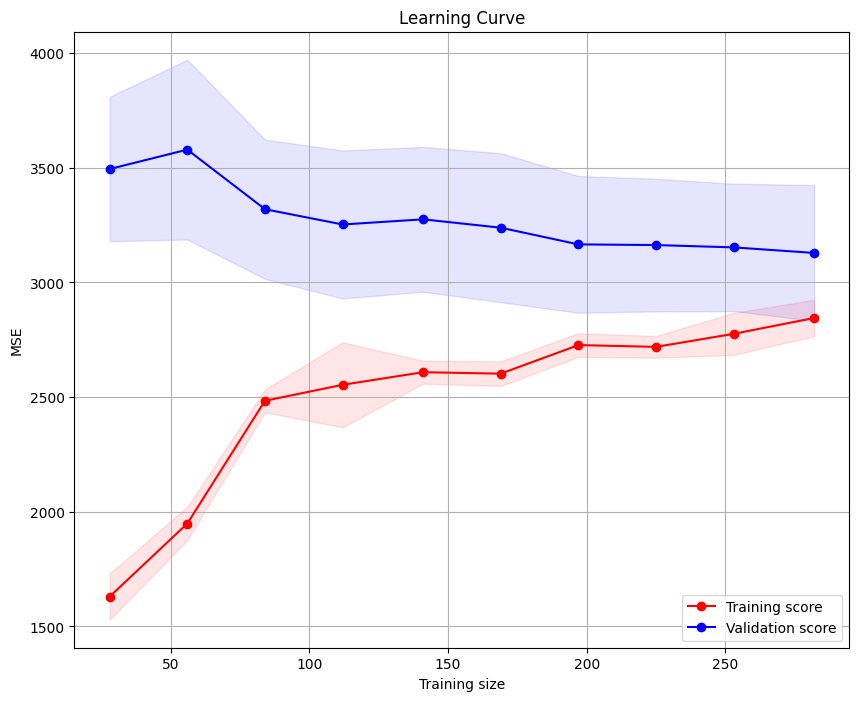

In [68]:
train_sizes, train_scores, test_scores = learning_curve(
    best_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="neg_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = -train_scores.mean(axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = -test_scores.mean(axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 8))
plt.plot(train_sizes, train_mean, 'o-', color='red', label='Training score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='red')
plt.plot(train_sizes, test_mean, 'o-', color='blue', label='Validation score')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='blue')
plt.xlabel("Training size")
plt.ylabel("MSE")
plt.title("Learning Curve")
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

Commento:

- Il grafico delle learning curve mostra che l’errore di training risulta leggermente superiore o simile a quello di validazione. 
- Questo comportamento può essere attribuito alla presenza di regolarizzazione nel modello (Ridge) e alla maggiore stabilità della cross-validation rispetto ai singoli subset di training. 
- Nel complesso, le curve risultano convergenti, indicando una buona capacità di generalizzazione.

### 5.  Visualizzazione con Data Reduction

In [69]:
scaler_pca = StandardScaler()
X_scaled_full = scaler_pca.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_full)

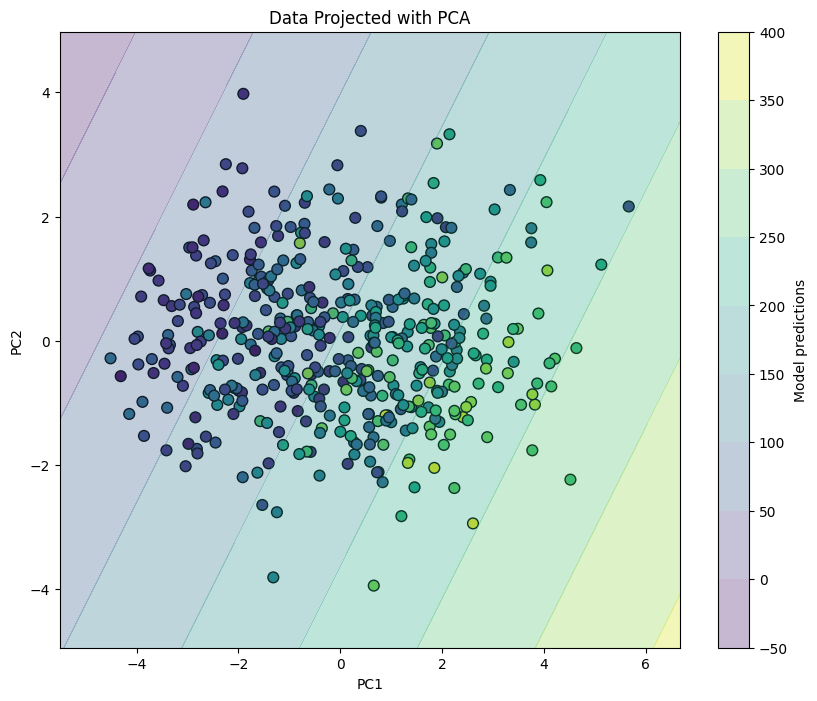

In [70]:
plt.figure(figsize=(10, 8))

plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='viridis', edgecolors='k', s=60)

x_min, x_max = X_pca[:,0].min()-1, X_pca[:,0].max()+1
y_min, y_max = X_pca[:,1].min()-1, X_pca[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

Z = model_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

contour = plt.contourf(xx, yy, Z, cmap='viridis', alpha=0.3)

plt.colorbar(contour, label="Model predictions")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Data Projected with PCA")
plt.show()

In [71]:
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

model_pca = Ridge(alpha=grid.best_params_["alpha"])
model_pca.fit(X_train_pca, y_train_pca)

y_pred_pca = model_pca.predict(X_test_pca)

print(f"MSE PCA:\t{mean_squared_error(y_test_pca, y_pred_pca):.4f}")
print(f"R2 PCA:\t\t{r2_score(y_test_pca, y_pred_pca):.4f}")

MSE PCA:	3527.1348
R2 PCA:		0.3343


In [72]:
pd.DataFrame(results, index=["NMSE"]).T.sort_values(by="NMSE")

,NMSE
Decision Tree,-6857.439841
SVM,-5223.465532
KNN,-3902.622546
Lasso,-3081.723030
Linear Regression,-3067.309455
Ridge,-3065.827157


Commento finale:

- I modelli lineari (Ridge, Lasso, Linear Regression) risultano i più performanti, indicando una relazione prevalentemente lineare nel dataset.
- Il Decision Tree mostra segni di overfitting, mentre KNN e SVM risultano meno efficaci senza un tuning approfondito.
- La PCA consente una buona visualizzazione dei dati ma comporta una perdita di informazione.